# A04 — Measurement, Sampling, and Collapse

**Track A — under the hood.** Pure NumPy. Qiskit is not imported anywhere in this
notebook. The random number generator is `np.random.default_rng`, seeded, and the
sampler is eleven lines you can read.

---

## The one-sentence version

"Measuring a qubit" sounds like one action. It is three, and keeping them apart
is most of what makes quantum computing make sense:

1. **You choose a basis.** There is no such thing as *the* value of a qubit.
   There is only its value *with respect to a question you picked*.
2. **You get a random outcome**, with probabilities given by the Born rule
   $P(k) = |\langle k|\psi\rangle|^2$. This is genuinely random — not
   ignorance about a value that was already there.
3. **The state is overwritten** by the outcome you got. The superposition is
   gone. Ask again and you get the same answer forever.

Almost every confusion about quantum computing is one of these three being
silently merged into the others. So we will build each one separately, in code.

## Why this notebook has a lot of statistics in it

Step 2 has a practical consequence that dominates real quantum computing: **you
never observe a probability, you only ever observe a tally.** A quantum computer
does not hand you $|\alpha|^2$. It hands you a bitstring. To learn the
probability you run the circuit $N$ times and count, and your answer is wrong by
roughly $1/\sqrt{N}$.

That square root is brutal. One more decimal digit of precision costs a hundred
times as many shots. It is the reason quantum algorithms work so hard to
*concentrate* amplitude on a single answer instead of reading a distribution off
the machine — and the reason "just take more shots" stops being an option
somewhere around four significant figures.

We will turn that $1/\sqrt{N}$ into a picture rather than a rule of thumb.

In [1]:
from qviz import backends, bloch, grid, style

import matplotlib.pyplot as plt
import numpy as np

style.use()

SEED = backends.seed_for("A04")
rng = np.random.default_rng(SEED)
print("seed:", SEED)

seed: 20260808


---

## Part 1 — the Born rule, written as a sampler

A state on $n$ qubits is a complex vector of length $2^n$. The Born rule says the
probability of outcome $k$ is

$$P(k) = |\langle k|\psi\rangle|^2 = |\psi_k|^2,$$

and since $\sum_k |\psi_k|^2 = 1$ by normalization, those numbers *are* a
probability distribution over the $2^n$ bitstrings. Sampling from a discrete
distribution is a solved problem: build the cumulative distribution, draw a
uniform $u \in [0,1)$, and find the first bin whose cumulative weight exceeds
$u$. That is the whole of `measure_shots` below.

Nothing quantum happens inside the sampler. The physics is entirely in the step
*before* it — the claim that the squared magnitude of a complex amplitude is a
probability. Everything after that is a loaded die.

**Endianness.** This repo is little-endian, matching Qiskit: index $i$ of the
statevector is the bitstring with **qubit 0 as the rightmost character**. So
index 2 of a 2-qubit register prints as `10`, meaning qubit 1 is set.

In [2]:
def probabilities(state):
    """Born rule: P(k) = |amplitude_k|^2."""
    p = np.abs(np.asarray(state)) ** 2
    return p / p.sum()          # guards against accumulated float drift


def measure_shots(state, shots, rng):
    """Sample `shots` outcome indices from |psi> by inverse-CDF sampling.

    No library sampler is used: this is the Born rule executed by hand, so that
    nothing about "where the randomness comes from" is hidden.
    """
    p = probabilities(state)
    cdf = np.cumsum(p)
    cdf[-1] = 1.0                       # exact right edge, whatever float did
    u = rng.random(shots)
    return np.searchsorted(cdf, u, side="right")


def counts(outcomes, dim):
    """Tally outcome indices into a length-`dim` count vector."""
    return np.bincount(outcomes, minlength=dim)


# A 2-qubit state whose four probabilities are deliberately uneven, with phases
# scattered around so we can watch the sampler ignore them completely.
TARGET_P = np.array([0.45, 0.05, 0.20, 0.30])
PHASES = np.array([0.0, np.pi / 2, np.pi, -np.pi / 4])
PSI = np.sqrt(TARGET_P) * np.exp(1j * PHASES)

LABELS = ["00", "01", "10", "11"]

print("state (little-endian, qubit 0 is the rightmost bit):")
print(grid.show_state(PSI))
print()
print("Born-rule probabilities:", np.round(probabilities(PSI), 4))
print("they sum to             ", probabilities(PSI).sum())
print()
demo = measure_shots(PSI, 12, rng)
print("12 raw shots (outcome indices):", demo)
print("as bitstrings                 :", [LABELS[i] for i in demo])

state (little-endian, qubit 0 is the rightmost bit):
  |00>  +0.6708+0.0000j
  |01>  +0.0000+0.2236j
  |10>  -0.4472+0.0000j
  |11>  +0.3873-0.3873j

Born-rule probabilities: [0.45 0.05 0.2  0.3 ]
they sum to              1.0

12 raw shots (outcome indices): [0 3 2 3 0 3 2 2 2 3 2 2]
as bitstrings                 : ['00', '11', '10', '11', '00', '11', '10', '10', '10', '11', '10', '10']


Twelve shots and you can already see the problem: the tally from twelve draws
is nowhere near $(0.45, 0.05, 0.20, 0.30)$. How far off should we expect it to
be, and how fast does that shrink?

## Figure 1 — the same state, seen through 8, 64, 512 and 4096 shots

Bars are the measured frequencies; the black dashes are the exact Born-rule
probabilities. This is one of the few places in the repo where a counts
histogram is genuinely the point — the *gap* between bar and dash is the whole
subject of this notebook.

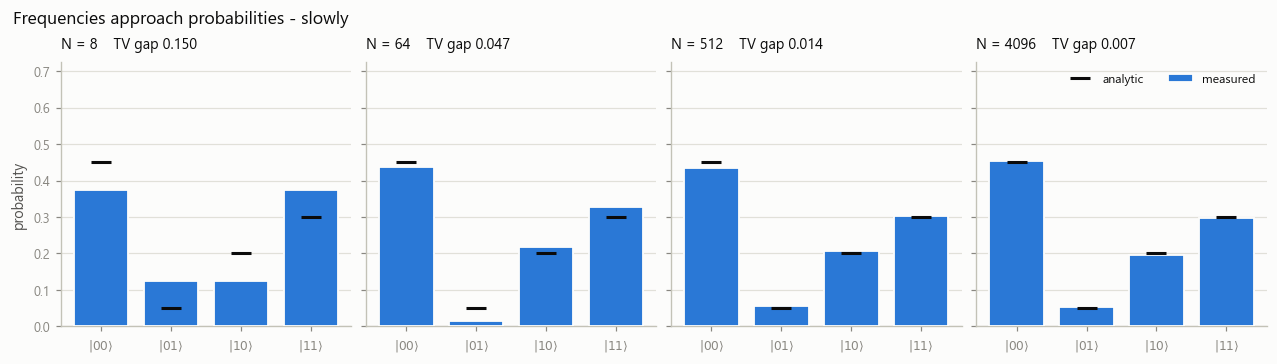

     N   total-variation gap   gap x sqrt(N)
     8                0.1500           0.424
    64                0.0469           0.375
   512                0.0145           0.327
  4096                0.0071           0.453


In [3]:
SHOT_SWEEP = [8, 64, 512, 4096]
p_exact = probabilities(PSI)

emps, tv_rows = [], []
for N in SHOT_SWEEP:
    emp = counts(measure_shots(PSI, N, rng), 4) / N
    emps.append(emp)
    tv_rows.append((N, 0.5 * np.abs(emp - p_exact).sum()))   # total variation

top = max(0.5, max(e.max() for e in emps)) * 1.45

fig, axes = plt.subplots(1, 4, figsize=(11.5, 3.2), sharey=True)
for ax, (N, tv), emp in zip(axes, tv_rows, emps):
    grid.prob_bars(ax, emp, analytic=p_exact, labels=LABELS)
    ax.set_ylim(0, top)
    ax.set_title(f"N = {N}    TV gap {tv:.3f}", loc="left", fontsize=9.5)
    if ax is not axes[0]:
        ax.set_ylabel("")
axes[-1].legend(loc="upper right", fontsize=8, ncols=2)
fig.suptitle("Frequencies approach probabilities - slowly", x=0.005, ha="left",
             fontsize=11.5)
plt.show()

print(f"{'N':>6}  {'total-variation gap':>20}  {'gap x sqrt(N)':>14}")
for N, tv in tv_rows:
    print(f"{N:6d}  {tv:20.4f}  {tv*np.sqrt(N):14.3f}")

Look at the third column. The gap shrinks, but the gap **times** $\sqrt{N}$
does not — it wanders around a constant. That is the signature of $1/\sqrt{N}$
convergence, and it is worth being precise about where it comes from.

## The shot-noise law, derived

Fix one outcome and call it a success with probability $p$. Each shot is an
independent Bernoulli trial, so the number of successes in $N$ shots is
binomial, and the estimator $\hat{p} = k/N$ has

$$\mathbb{E}[\hat p] = p, \qquad \operatorname{Var}[\hat p] = \frac{p(1-p)}{N},
\qquad \sigma[\hat p] = \sqrt{\frac{p(1-p)}{N}}.$$

Two things follow immediately.

- **The estimator is unbiased.** No amount of shot noise pushes the answer
  systematically off. More shots is the *only* thing you need.
- **The error falls as $N^{-1/2}$.** Since $p(1-p) \le 1/4$, the worst case is
  $\sigma \le 1/(2\sqrt N)$ — which is where the folk rule "error $\approx
  1/\sqrt N$" comes from. It is an upper bound, and it is tightest at $p = 1/2$.

To reach an absolute error $\varepsilon$ with 95% confidence you need roughly
$N \approx 1.96^2\,p(1-p)/\varepsilon^2$ shots. Quadratic in $1/\varepsilon$.
That single fact shapes the design of every quantum algorithm in this repo.

## Figure 2 — the shot-convergence fan

Fifty independent experiments, each running out to 8192 shots on a state with
$P(0) = 0.7$. Every translucent line is one experiment's running estimate. The
shaded bands are the analytic $\pm 1\sigma$ and $\pm 2\sigma$ envelopes — drawn,
not fitted.

The left panel is "what does shot noise look like". The right panel is the
answer to the only question anyone actually asks: **how many shots do I need?**

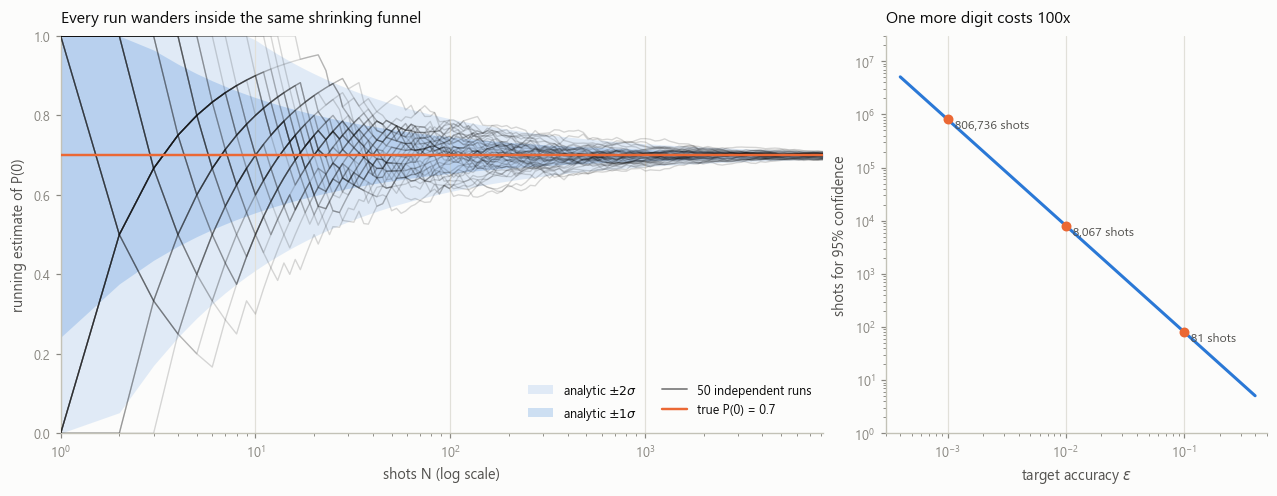

N =    16   sigma = 0.1146   runs within 1 sigma: 70%  (expected ~68%)
N =   258   sigma = 0.0285   runs within 1 sigma: 60%  (expected ~68%)
N =  4150   sigma = 0.0071   runs within 1 sigma: 62%  (expected ~68%)


In [4]:
P_TRUE = 0.7
N_MAX, RUNS = 8192, 50

# A real qubit state, not an abstract coin: |psi> = sqrt(0.7)|0> + sqrt(0.3)|1>,
# measured in the computational basis.
PSI_FAN = np.array([np.sqrt(P_TRUE), np.sqrt(1 - P_TRUE)], dtype=complex)

shots_all = measure_shots(PSI_FAN, RUNS * N_MAX, rng).reshape(RUNS, N_MAX)
hit_zero = (shots_all == 0).astype(float)
running = np.cumsum(hit_zero, axis=1) / np.arange(1, N_MAX + 1)

# Log-spaced sample points: 50 x 8192 plotted in full is 400k vertices for no
# extra information, and the PNG budget is 500 KB.
ticks = np.unique(np.round(np.logspace(0, np.log10(N_MAX), 160)).astype(int))
curves = running[:, ticks - 1]

sigma = np.sqrt(P_TRUE * (1 - P_TRUE) / ticks)

fig = plt.figure(figsize=(11.5, 4.4))
gs = fig.add_gridspec(1, 3)
axf = fig.add_subplot(gs[0, :2])
axn = fig.add_subplot(gs[0, 2])

axf.fill_between(ticks, np.clip(P_TRUE - 2 * sigma, 0, 1),
                 np.clip(P_TRUE + 2 * sigma, 0, 1),
                 color=style.BLUE, alpha=0.13, lw=0, zorder=1,
                 label=r"analytic $\pm 2\sigma$")
axf.fill_between(ticks, np.clip(P_TRUE - sigma, 0, 1),
                 np.clip(P_TRUE + sigma, 0, 1),
                 color=style.BLUE, alpha=0.22, lw=0, zorder=2,
                 label=r"analytic $\pm 1\sigma$")
for row in curves:
    axf.plot(ticks, row, color=style.INK, alpha=0.16, lw=0.9, zorder=3)
axf.plot([], [], color=style.INK, alpha=0.5, lw=1.2, label="50 independent runs")
axf.axhline(P_TRUE, color=style.ORANGE, lw=1.6, zorder=4,
            label=f"true P(0) = {P_TRUE}")

axf.set_xscale("log")
axf.set_xlim(1, N_MAX)
axf.set_ylim(0, 1)
axf.set_xlabel("shots N (log scale)")
axf.set_ylabel("running estimate of P(0)")
axf.set_title("Every run wanders inside the same shrinking funnel",
              loc="left", fontsize=10.5)
axf.legend(loc="lower right", fontsize=8.2, ncols=2)
axf.grid(axis="both")

eps = np.logspace(-3.4, -0.4, 200)
n_needed = 1.96 ** 2 * P_TRUE * (1 - P_TRUE) / eps ** 2
axn.plot(eps, n_needed, color=style.BLUE, lw=2.0, zorder=3)
for e in (0.1, 0.01, 0.001):
    n = 1.96 ** 2 * P_TRUE * (1 - P_TRUE) / e ** 2
    axn.plot([e], [n], marker="o", ms=5.5, color=style.ORANGE, zorder=4)
    axn.annotate(f"  {n:,.0f} shots", (e, n), fontsize=8, color=style.INK_2,
                 ha="left", va="top")
axn.set_xscale("log")
axn.set_yscale("log")
axn.set_xlim(3e-4, 0.5)
axn.set_ylim(1, 3e7)
axn.set_xlabel(r"target accuracy $\varepsilon$")
axn.set_ylabel("shots for 95% confidence")
axn.set_title("One more digit costs 100x", loc="left", fontsize=10.5)
axn.grid(axis="both")

plt.show()

for N in (16, 256, 4096):
    j = int(np.argmin(np.abs(ticks - N)))
    inside = np.mean(np.abs(curves[:, j] - P_TRUE) <= sigma[j])
    print(f"N = {ticks[j]:5d}   sigma = {sigma[j]:.4f}   "
          f"runs within 1 sigma: {inside*100:.0f}%  (expected ~68%)")

Three things this picture says that the formula does not.

- **The funnel is not a guarantee.** Individual lines leave the $\pm 1\sigma$
  band constantly — about a third of the time, by construction. A single
  experiment landing outside the band is not evidence of a bug.
- **Early shots are worthless for precision and are not wasted.** The left edge
  is chaos: with $N = 4$ the estimate can only be $0, 0.25, 0.5, 0.75, 1$. The
  useful regime starts around a few hundred shots.
- **The lines are strongly autocorrelated.** A run that drifts high stays high
  for a while, because shot $N{+}1$ only moves the running mean by $1/N$. That
  is why the fan looks like smooth threads instead of noise — and why "it
  looked converged" is not the same as "it converged".

---

## Part 2 — projectors, and the update that makes measurement irreversible

Sampling gives you step 2 of the three. Step 3 is the part that has no classical
analogue, and it is written with **projection operators**.

For the computational basis of a single qubit,

$$P_0 = |0\rangle\langle 0| = \begin{pmatrix}1 & 0\\ 0 & 0\end{pmatrix},
\qquad
P_1 = |1\rangle\langle 1| = \begin{pmatrix}0 & 0\\ 0 & 1\end{pmatrix}.$$

They satisfy three properties that define a **projective measurement**:

$$P_k^\dagger = P_k \quad\text{(Hermitian)}, \qquad
P_k^2 = P_k \quad\text{(idempotent)}, \qquad
\sum_k P_k = I \quad\text{(complete)}.$$

Completeness is what makes the probabilities add to one. Given those, the rule is

$$P(k) = \langle\psi|P_k|\psi\rangle, \qquad
|\psi\rangle \;\longmapsto\; \frac{P_k|\psi\rangle}{\sqrt{\langle\psi|P_k|\psi\rangle}}.$$

The numerator kills every amplitude except the ones consistent with the outcome.
The denominator puts the survivors back on the unit sphere — **that
renormalization is the collapse**, and it is the only non-linear, non-unitary,
irreversible step anywhere in quantum mechanics. Every gate in every other
notebook in this repo is a unitary you could run backwards. This one you cannot:
the division by $\sqrt{P(k)}$ has thrown away the amplitude that used to be
there, and no operation recovers it.

In [5]:
I2 = np.eye(2, dtype=complex)
KET0 = np.array([1, 0], dtype=complex)
KET1 = np.array([0, 1], dtype=complex)


def projector(ket):
    """P = |k><k| for a normalized column vector."""
    k = np.asarray(ket, dtype=complex).reshape(-1, 1)
    return k @ k.conj().T


P0, P1 = projector(KET0), projector(KET1)

print("P0 =\n", P0.real.astype(int))
print("P1 =\n", P1.real.astype(int))
print()
print("Hermitian?  ", np.allclose(P0, P0.conj().T), np.allclose(P1, P1.conj().T))
print("Idempotent? ", np.allclose(P0 @ P0, P0), np.allclose(P1 @ P1, P1))
print("Complete?   ", np.allclose(P0 + P1, I2))

P0 =
 [[1 0]
 [0 0]]
P1 =
 [[0 0]
 [0 1]]

Hermitian?   True True
Idempotent?  True True
Complete?    True


In [6]:
def born_probability(state, P):
    """P(k) = <psi|P_k|psi>. Real by construction; we take .real to drop dust."""
    psi = np.asarray(state, dtype=complex)
    return float(np.real(psi.conj() @ (P @ psi)))


def collapse(state, P):
    """Post-measurement state: project, then RENORMALIZE. Returns (state, p)."""
    psi = np.asarray(state, dtype=complex)
    projected = P @ psi
    p = float(np.real(psi.conj() @ projected))
    if p < 1e-15:
        raise ValueError("outcome has probability zero; it cannot occur")
    return projected / np.sqrt(p), p


# A state that is genuinely in superposition, with a relative phase so we can
# watch the phase information get destroyed rather than merely reshuffled.
PSI_1Q = np.array([np.sqrt(0.8), np.sqrt(0.2) * np.exp(1j * np.pi / 4)])

print("before measurement:", np.round(PSI_1Q, 4))
print("  P(0) = <psi|P0|psi> =", round(born_probability(PSI_1Q, P0), 6))
print("  P(1) = <psi|P1|psi> =", round(born_probability(PSI_1Q, P1), 6))
print()

for name, P in [("outcome 0", P0), ("outcome 1", P1)]:
    raw = P @ PSI_1Q
    post, p = collapse(PSI_1Q, P)
    print(f"{name}:  P psi (un-normalized) = {np.round(raw, 4)}"
          f"   norm = {np.linalg.norm(raw):.4f}")
    print(f"           after dividing by sqrt(p) = {np.round(post, 4)}"
          f"   norm = {np.linalg.norm(post):.4f}")

before measurement: [0.8944+0.j     0.3162+0.3162j]
  P(0) = <psi|P0|psi> = 0.8
  P(1) = <psi|P1|psi> = 0.2

outcome 0:  P psi (un-normalized) = [0.8944+0.j 0.    +0.j]   norm = 0.8944
           after dividing by sqrt(p) = [1.+0.j 0.+0.j]   norm = 1.0000
outcome 1:  P psi (un-normalized) = [0.    +0.j     0.3162+0.3162j]   norm = 0.4472
           after dividing by sqrt(p) = [0.    +0.j     0.7071+0.7071j]   norm = 1.0000


Read the un-normalized line carefully. $P_1|\psi\rangle$ has norm
$\sqrt{0.2} \approx 0.447$ — it is *not* a state. Dividing by $\sqrt{p}$ is not
bookkeeping; it is the step that converts "the part of the amplitude that agreed
with my result" into a full-fledged state again. It is also where the
information goes: after the division, nothing in the vector remembers that
$P(1)$ was 0.2 rather than 0.999.

And the relative phase $e^{i\pi/4}$ survives collapse only as a **global** phase
on the surviving component — which A01 showed is unobservable. So the phase is
gone too.

### Measuring twice is not sampling twice

This is the most common practical error in reading quantum experiments. After a
measurement, the state is an eigenstate of the thing you measured. Measure it
again and the answer is not a fresh sample — it is a photocopy.

In [7]:
state = PSI_1Q.copy()
print("repeated measurement of the SAME qubit (no reset in between):")
for step in range(6):
    p0 = born_probability(state, P0)
    k = 0 if rng.random() < p0 else 1
    state, _ = collapse(state, P0 if k == 0 else P1)
    print(f"  measurement {step+1}: P(0) was {p0:.3f}  ->  outcome {k}")

print()
print("After the first shot P(0) is pinned at 0 or 1: the state stopped being")
print("a superposition, so every later shot is deterministic. Real shot")
print("statistics require re-preparing the state from scratch each time.")

repeated measurement of the SAME qubit (no reset in between):
  measurement 1: P(0) was 0.800  ->  outcome 0
  measurement 2: P(0) was 1.000  ->  outcome 0
  measurement 3: P(0) was 1.000  ->  outcome 0
  measurement 4: P(0) was 1.000  ->  outcome 0
  measurement 5: P(0) was 1.000  ->  outcome 0
  measurement 6: P(0) was 1.000  ->  outcome 0

After the first shot P(0) is pinned at 0 or 1: the state stopped being
a superposition, so every later shot is deterministic. Real shot
statistics require re-preparing the state from scratch each time.


## Figure 3 — the collapse cartoon

The Bloch sphere makes the three steps visible in one frame. On the left, the
pre-measurement state: a vector pointing somewhere off-axis, which is what
"superposition of $|0\rangle$ and $|1\rangle$ with a relative phase" looks like
geometrically. On the right, the only two places it can end up — the poles.

The arrow widths are proportional to the two outcome probabilities. Note that
**both** post-measurement spheres are drawn: the state does not split, and it
does not average. One of them happens, at random, and the other never existed.

The Bloch vector is $\vec r = (\langle X\rangle, \langle Y\rangle, \langle Z\rangle)$,
computed inline from the Pauli matrices — `qviz` only draws the arrow.

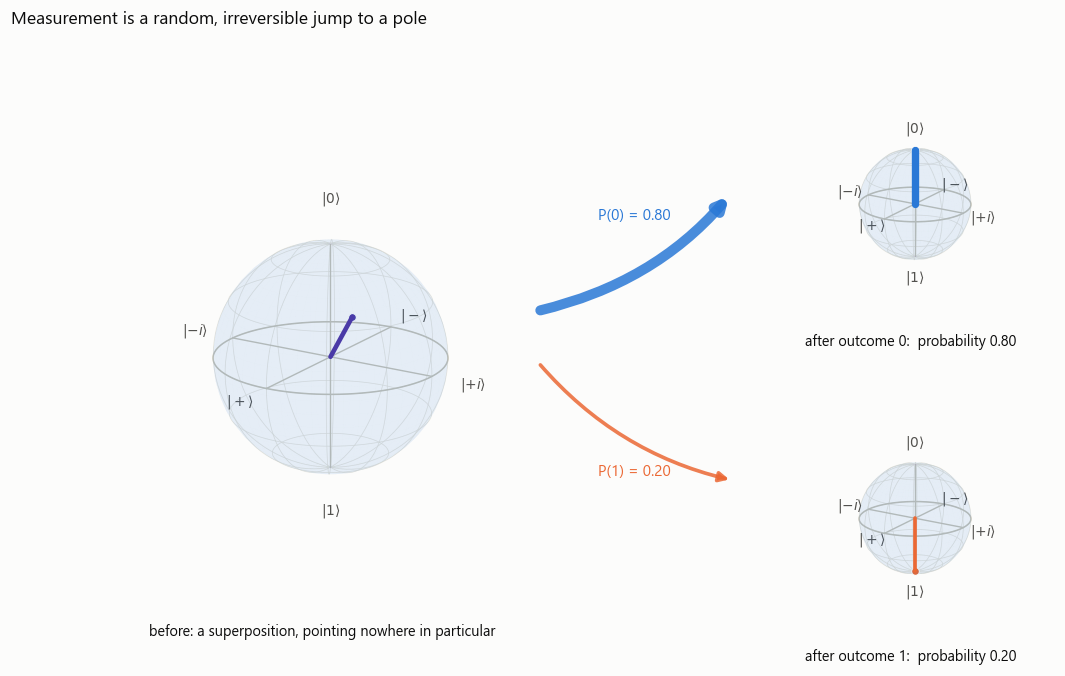

Bloch vector before : [0.5657 0.5657 0.6   ]  length 1.0
Bloch vector after 0: [0. 0. 1.]
Bloch vector after 1: [ 0.  0. -1.]

Averaging the two outcomes weighted by probability gives z = 0.6 = <Z> before. The average is NOT the state: it is a bookkeeping
identity, and the x and y components do not survive it.


In [8]:
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)


def bloch_vector(state):
    """r = (<X>, <Y>, <Z>) - the whole of a pure qubit, as three real numbers."""
    psi = np.asarray(state, dtype=complex)
    return np.array([float(np.real(psi.conj() @ (M @ psi))) for M in (X, Y, Z)])


r_pre = bloch_vector(PSI_1Q)
post0, prob0 = collapse(PSI_1Q, P0)
post1, prob1 = collapse(PSI_1Q, P1)
r_post = [bloch_vector(post0), bloch_vector(post1)]

# layout="none" (the string): passing None falls through to the constrained-layout
# rcParam, which would silently discard subplots_adjust.
fig = plt.figure(figsize=(10.6, 6.2), layout="none")
gs = fig.add_gridspec(2, 2, width_ratios=[1.22, 1.0])
axL = fig.add_subplot(gs[:, 0], projection="3d")
axT = fig.add_subplot(gs[0, 1], projection="3d")
axB = fig.add_subplot(gs[1, 1], projection="3d")
fig.subplots_adjust(left=0.0, right=1.0, top=0.90, bottom=0.02,
                    wspace=0.02, hspace=0.10)

bloch.sphere(axL)
bloch.vector(axL, r_pre, color=style.VIOLET, lw=3.0)
bloch.label(axL, "before: a superposition, pointing nowhere in particular",
            y=0.07, size=9.5)

for ax, r, p, col, name in [(axT, r_post[0], prob0, style.BLUE, "0"),
                            (axB, r_post[1], prob1, style.ORANGE, "1")]:
    bloch.sphere(ax, labels=True)
    bloch.vector(ax, r, color=col, lw=1.6 + 4.0 * p)
    bloch.label(ax, f"after outcome {name}:  probability {p:.2f}",
                y=0.06, size=9.5)

for y_from, y_to, p, col, name in [(0.55, 0.76, prob0, style.BLUE, "0"),
                                   (0.45, 0.24, prob1, style.ORANGE, "1")]:
    ax_arrow = fig.add_axes([0.45, 0.10, 0.18, 0.80], zorder=5)
    ax_arrow.set_axis_off()
    ax_arrow.set_xlim(0, 1)
    ax_arrow.set_ylim(0, 1)
    ax_arrow.patch.set_alpha(0.0)
    ax_arrow.annotate("", xy=(0.95, y_to), xytext=(0.05, y_from),
                      arrowprops=dict(arrowstyle="-|>", color=col,
                                      lw=1.0 + 7.0 * p, alpha=0.85,
                                      shrinkA=0, shrinkB=0, mutation_scale=13,
                                      connectionstyle="arc3,rad=0.16"))
    ax_arrow.text(0.5, (y_from + y_to) / 2 + (0.07 if p == prob0 else -0.09),
                  f"P({name}) = {p:.2f}", color=col, fontsize=10,
                  ha="center", va="center", weight="medium")

fig.suptitle("Measurement is a random, irreversible jump to a pole",
             x=0.005, ha="left", fontsize=11.5)
plt.show()

print("Bloch vector before :", np.round(r_pre, 4), " length",
      round(float(np.linalg.norm(r_pre)), 4))
print("Bloch vector after 0:", np.round(r_post[0], 4))
print("Bloch vector after 1:", np.round(r_post[1], 4))
print()
print("Averaging the two outcomes weighted by probability gives z =",
      round(prob0 * r_post[0][2] + prob1 * r_post[1][2], 4),
      "= <Z> before. The average is NOT the state: it is a bookkeeping")
print("identity, and the x and y components do not survive it.")

That last print is worth pausing on. The probability-weighted average of the
two post-measurement $z$ components equals $\langle Z\rangle$ of the original
state — the statistics are consistent. But the averaged $x$ and $y$ components
are zero, while the original state had both. The ensemble average is not a state
on the sphere at all; it is a **mixed state**, living strictly inside the ball.
That is exactly the object A12 needs a density matrix for.

---

## Part 3 — you cannot measure without choosing a question

Step 1, finally, and it is the one most tutorials skip.

$P_0, P_1$ projected onto $|0\rangle$ and $|1\rangle$ because we chose them to.
Nothing forces that choice. Any orthonormal basis $\{|b_0\rangle, |b_1\rangle\}$
gives a valid projective measurement with $P_k = |b_k\rangle\langle b_k|$, and

$$P(k) = |\langle b_k|\psi\rangle|^2.$$

The three standard choices are the eigenbases of the three Pauli operators:

| basis | outcome $+1$ | outcome $-1$ | measures |
|---|---|---|---|
| $Z$ | $|0\rangle$ | $|1\rangle$ | $\langle Z\rangle$ |
| $X$ | $|+\rangle = \frac{1}{\sqrt2}(|0\rangle + |1\rangle)$ | $|-\rangle = \frac{1}{\sqrt2}(|0\rangle - |1\rangle)$ | $\langle X\rangle$ |
| $Y$ | $|{+}i\rangle = \frac{1}{\sqrt2}(|0\rangle + i|1\rangle)$ | $|{-}i\rangle = \frac{1}{\sqrt2}(|0\rangle - i|1\rangle)$ | $\langle Y\rangle$ |

Real hardware can only measure in $Z$. So the way you measure in some other
basis $B$ is to **rotate the basis onto $Z$ first**: apply the unitary $U$ whose
rows are $\langle b_k|$, then do a normal $Z$ measurement. Those two recipes are
the same arithmetic, and we check that below rather than asserting it.

In [9]:
SQ = 1 / np.sqrt(2)
BASES = {
    "Z": (np.array([[1, 0], [0, 1]], dtype=complex), ["0", "1"]),
    "X": (np.array([[SQ, SQ], [SQ, -SQ]], dtype=complex), ["+", "-"]),
    "Y": (np.array([[SQ, -1j * SQ], [SQ, 1j * SQ]], dtype=complex),
          ["{+}i", "{-}i"]),
}
# Each matrix U has the basis BRAS as its rows, so U @ psi is the amplitude
# vector in that basis. U is unitary exactly because the basis is orthonormal.

STATES = {
    "0": KET0,
    "+": np.array([SQ, SQ], dtype=complex),
    "{+}i": np.array([SQ, 1j * SQ], dtype=complex),
}


def probs_in_basis(state, U):
    """P(k) = |<b_k|psi>|^2, with <b_k| the rows of U."""
    return np.abs(U @ np.asarray(state, dtype=complex)) ** 2


for name, (U, _) in BASES.items():
    print(f"basis {name}: unitary?", np.allclose(U @ U.conj().T, I2))

psi = STATES["+"]
U = BASES["Y"][0]
by_projector = np.array([born_probability(psi, projector(U[k].conj()))
                         for k in (0, 1)])
by_rotation = probabilities(U @ psi)
print()
print("|+> measured in the Y basis")
print("  via projectors |b_k><b_k| :", np.round(by_projector, 6))
print("  via rotate-then-Z-measure :", np.round(by_rotation, 6))
print("  identical?", np.allclose(by_projector, by_rotation))

basis Z: unitary? True
basis X: unitary? True
basis Y: unitary? True

|+> measured in the Y basis
  via projectors |b_k><b_k| : [0.5 0.5]
  via rotate-then-Z-measure : [0.5 0.5]
  identical? True


## Figure 4 — the same state, three questions

Rows are states; columns are the basis you chose to measure in. Bars are 2048
sampled shots, dashes are the exact probabilities.

The diagonal is certainty. Everything off it is a fair coin. **The state did not
change between the columns — only the question did.**

So "what is the value of this qubit?" is not a well-posed question, in the same
way "what is the length of this vector's first component?" is not well posed
until you name a coordinate system. $|+\rangle$ does not secretly have a $Z$
value that we are too clumsy to read; it has a definite $X$ value and no $Z$
value at all.

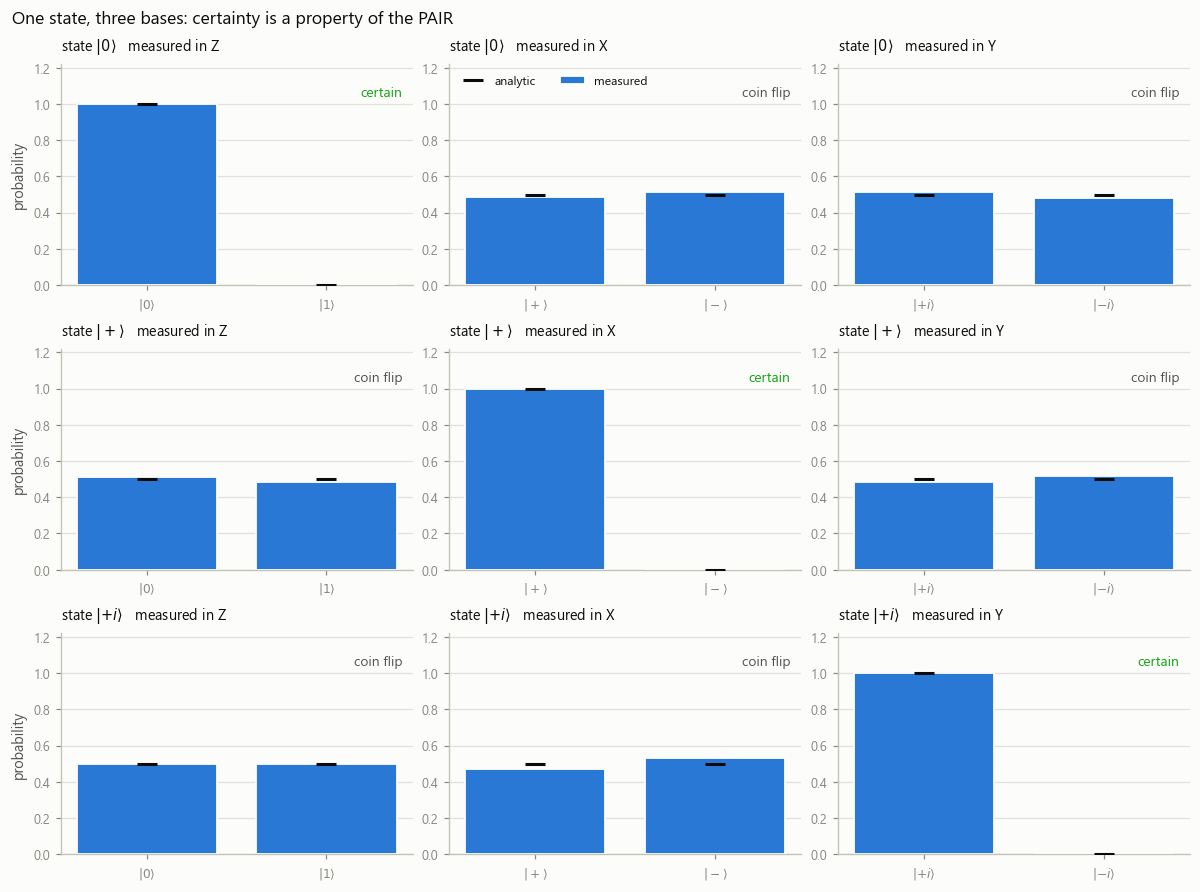

  state             Z basis             X basis             Y basis
      0             [1. 0.]           [0.5 0.5]           [0.5 0.5]
      +           [0.5 0.5]             [1. 0.]           [0.5 0.5]
   {+}i           [0.5 0.5]           [0.5 0.5]             [1. 0.]


In [10]:
N_BASIS = 2048

fig, axes = plt.subplots(3, 3, figsize=(10.8, 8.0))
for i, (sname, s) in enumerate(STATES.items()):
    for j, (bname, (U, blabels)) in enumerate(BASES.items()):
        ax = axes[i, j]
        exact = probs_in_basis(s, U)
        rotated = U @ s                      # amplitudes in the chosen basis
        emp = counts(measure_shots(rotated, N_BASIS, rng), 2) / N_BASIS
        grid.prob_bars(ax, emp, analytic=exact, labels=blabels)
        ax.set_ylim(0, 1.22)
        ax.set_title(f"state {grid.ket(sname)}   measured in {bname}",
                     loc="left", fontsize=9.5)
        verdict = "certain" if exact.max() > 0.99 else "coin flip"
        col = style.GOOD if exact.max() > 0.99 else style.INK_2
        ax.text(0.97, 0.90, verdict, transform=ax.transAxes, ha="right",
                va="top", fontsize=9, color=col, weight="medium")
        if j:
            ax.set_ylabel("")
axes[0, 1].legend(loc="upper left", fontsize=8, ncols=2)
fig.suptitle("One state, three bases: certainty is a property of the PAIR",
             x=0.005, ha="left", fontsize=11.5)
plt.show()

print(f"{'state':>7}  {'Z basis':>18}  {'X basis':>18}  {'Y basis':>18}")
for sname, s in STATES.items():
    row = "  ".join(f"{str(np.round(probs_in_basis(s, U), 3)):>18}"
                    for U, _ in BASES.values())
    print(f"{sname:>7}  {row}")

There is a conservation law hiding in that table. For a pure qubit,

$$\langle X\rangle^2 + \langle Y\rangle^2 + \langle Z\rangle^2 = 1,$$

which is just "the Bloch vector has length 1". Certainty in one basis
($\langle Z\rangle = \pm 1$) therefore *forces* $\langle X\rangle =
\langle Y\rangle = 0$ — a perfect coin flip in both other bases. You cannot buy
sharpness in $X$ except by spending it from $Z$ and $Y$. That is the
uncertainty principle for a qubit, and it is a statement about geometry, not
about clumsy instruments.

---

## Part 4 — is our sampler actually honest?

We wrote `measure_shots` ourselves, so we should not take its correctness on
faith. The test: run many independent experiments, and for each one compute
Pearson's chi-squared statistic against the exact Born probabilities,

$$\chi^2 = \sum_k \frac{(O_k - E_k)^2}{E_k}, \qquad E_k = N\,P(k),$$

which for a two-outcome experiment has 1 degree of freedom. Convert each to a
$p$-value.

Here is the part that makes this a *visual* check rather than a single number.
If the sampler is unbiased, the $p$-values from many trials must be **uniform on
$[0,1]$** — not "mostly large", not "mostly small", uniform. A histogram sagging
towards zero means the sampler is biased; a histogram piled at one means it is
suspiciously well-behaved (a real diagnosis in fabricated data). Uniformity is a
much sharper test than "the mean looks right".

In [11]:
from scipy import stats

TRIALS, N_TRIAL = 4000, 400
PSI_TEST = np.array([np.sqrt(0.62), np.sqrt(0.38) * 1j])   # phase must not matter
p_test = probabilities(PSI_TEST)

raw = measure_shots(PSI_TEST, TRIALS * N_TRIAL, rng).reshape(TRIALS, N_TRIAL)
obs0 = (raw == 0).sum(axis=1)
observed = np.stack([obs0, N_TRIAL - obs0], axis=1)
expected = N_TRIAL * p_test

chi2 = ((observed - expected) ** 2 / expected).sum(axis=1)
pvals = stats.chi2.sf(chi2, df=1)

print(f"{TRIALS} trials of {N_TRIAL} shots each on P(0) = {p_test[0]:.2f}")
print(f"  mean of p-values      : {pvals.mean():.4f}   (uniform -> 0.5)")
print(f"  fraction p < 0.05     : {np.mean(pvals < 0.05):.4f}   (expect ~0.05)")
print(f"  fraction p < 0.01     : {np.mean(pvals < 0.01):.4f}   (expect ~0.01)")
print(f"  mean chi2 statistic   : {chi2.mean():.4f}   (expect ~1.0 for df=1)")
ks = stats.kstest(pvals, "uniform")
print(f"  KS test vs uniform    : D = {ks.statistic:.4f}, p = {ks.pvalue:.4f}")

4000 trials of 400 shots each on P(0) = 0.62
  mean of p-values      : 0.4948   (uniform -> 0.5)
  fraction p < 0.05     : 0.0498   (expect ~0.05)
  fraction p < 0.01     : 0.0132   (expect ~0.01)
  mean chi2 statistic   : 1.0445   (expect ~1.0 for df=1)
  KS test vs uniform    : D = 0.0457, p = 0.0000


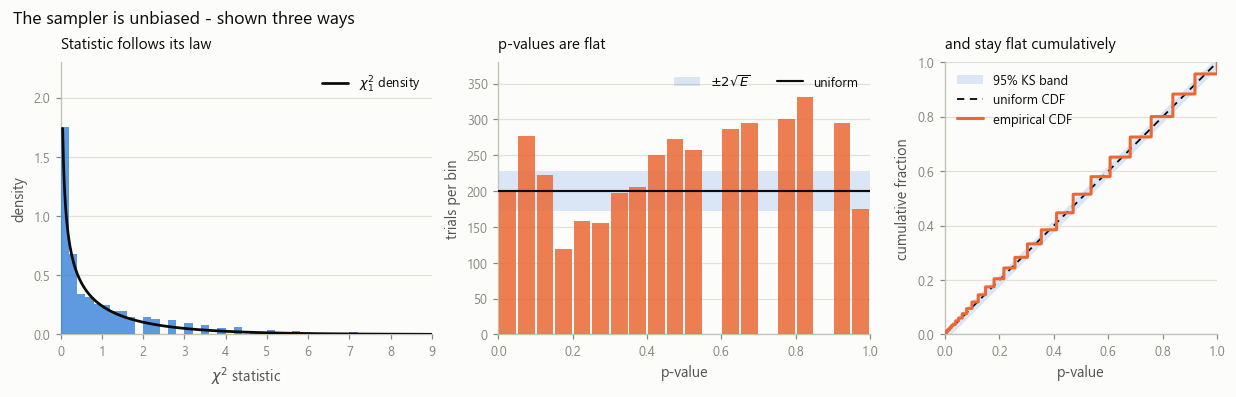

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.5))

ax = axes[0]
xs = np.linspace(0.05, 9, 400)
ax.hist(chi2, bins=np.linspace(0, 9, 46), density=True, color=style.BLUE,
        alpha=0.75, zorder=3)
ax.plot(xs, stats.chi2.pdf(xs, df=1), color=style.INK, lw=1.8, zorder=4,
        label=r"$\chi^2_1$ density")
ax.set_xlim(0, 9)
ax.set_ylim(0, 2.3)
ax.set_xlabel(r"$\chi^2$ statistic")
ax.set_ylabel("density")
ax.set_title("Statistic follows its law", loc="left", fontsize=10)
ax.legend(fontsize=8.5)

ax = axes[1]
nb = 20
cnt, edges = np.histogram(pvals, bins=nb, range=(0, 1))
mid = 0.5 * (edges[:-1] + edges[1:])
exp_cnt = TRIALS / nb
band = 2 * np.sqrt(exp_cnt)
ax.fill_between([0, 1], exp_cnt - band, exp_cnt + band, color=style.BLUE,
                alpha=0.16, lw=0, zorder=1, label=r"$\pm 2\sqrt{E}$")
ax.axhline(exp_cnt, color=style.INK, lw=1.4, zorder=4, label="uniform")
ax.bar(mid, cnt, width=1 / nb * 0.9, color=style.ORANGE, alpha=0.85, zorder=3)
ax.set_xlim(0, 1)
ax.set_ylim(0, exp_cnt * 1.9)
ax.set_xlabel("p-value")
ax.set_ylabel("trials per bin")
ax.set_title("p-values are flat", loc="left", fontsize=10)
ax.legend(fontsize=8.5, loc="upper right", ncols=2)

ax = axes[2]
srt = np.sort(pvals)
ecdf = np.arange(1, TRIALS + 1) / TRIALS
kb = 1.36 / np.sqrt(TRIALS)          # 95% Kolmogorov-Smirnov band
ax.fill_between([0, 1], [-kb, 1 - kb], [kb, 1 + kb], color=style.BLUE,
                alpha=0.16, lw=0, zorder=1, label="95% KS band")
ax.plot([0, 1], [0, 1], color=style.INK, lw=1.2, ls=(0, (4, 3)), zorder=3,
        label="uniform CDF")
ax.plot(srt, ecdf, color=style.ORANGE, lw=2.0, zorder=4, label="empirical CDF")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect("equal")
ax.set_xlabel("p-value")
ax.set_ylabel("cumulative fraction")
ax.set_title("and stay flat cumulatively", loc="left", fontsize=10)
ax.legend(fontsize=8.5, loc="upper left")

fig.suptitle("The sampler is unbiased - shown three ways", x=0.005, ha="left",
             fontsize=11.5)
plt.show()

The $p$-value histogram is flat to within its own Poisson error bars, and the
empirical CDF stays inside the Kolmogorov–Smirnov band. The sampler is doing
what the Born rule says.

**One honest wrinkle.** The counts are integers, so $\chi^2$ can only take
discrete values and the $p$-value distribution is really a fine lattice, not a
continuum. At $N = 400$ the lattice is fine enough to look continuous; drop to
$N = 10$ and the histogram develops visible teeth even though nothing is wrong.
A $p$-value from a discrete statistic is *conservative*, and a KS test against a
continuous uniform is being slightly unfair to it. Worth knowing before you use
this test on a small-shot experiment and conclude your hardware is broken.

---

## Honest limits

**Projective measurement is not the most general measurement.** The
$\{P_k\}$ story — Hermitian, idempotent, complete — is the textbook case, and it
is what a computational-basis readout does. But the general object is a **POVM**:
a set of positive operators $\{E_k\}$ with $\sum_k E_k = I$, dropping the
idempotence requirement. POVMs let you do things projectors cannot, such as
*unambiguous state discrimination*: a three-outcome measurement that says
"definitely $|0\rangle$", "definitely $|+\rangle$", or "I decline to answer",
and is never wrong when it does answer. Any POVM can be realised as a projective
measurement on a larger system (Naimark), which is why we can get away with
projectors here — but "measurement = projector" is a simplification.

**Repeated measurement is not repeated sampling.** Part 2 showed it: after the
first shot the state is an eigenstate and every subsequent read is a copy.
Everything in Part 1 assumed $N$ shots means $N$ *fresh preparations* of the
circuit. If you ever see a shot loop that measures without re-preparing, the
error bars it reports are fiction.

**Nothing here is noisy.** Real readout misassigns 0 for 1 at the percent level,
and that is a *bias*, not shot noise: it does not shrink as $1/\sqrt N$, so past
about $10^4$ shots you are measuring your readout error rather than your state.
A12 and B26 deal with that.

**The $1/\sqrt N$ wall is the real cost model.** Estimating a probability to
four decimals needs $\sim 10^8$ shots. That is why a quantum algorithm is never
designed to hand you a distribution and let you read it: it is designed so that
amplitude piles up on a single bitstring and a few hundred shots suffice.
Grover's amplitude amplification (A10) and phase estimation (A11) are both,
read one way, purely engineering responses to this figure. And it is the reason
naive "quantum machine learning" schemes that read out a real number per query
tend to give the speedup straight back.

**Collapse here is a rule, not an explanation.** We implemented the projection
postulate. Why the universe applies it — decoherence, many worlds, something
else — is untouched, and mercifully irrelevant to computing the right answer.

## Checkpoint

In [13]:
check = np.random.default_rng(SEED + 1)

# 1. Born-rule probabilities are a distribution.
for st in (PSI, PSI_1Q, PSI_TEST, PSI_FAN):
    p = probabilities(st)
    assert np.all(p >= 0) and np.isclose(p.sum(), 1.0)

# 2. Projectors are Hermitian, idempotent and complete.
for U, _ in BASES.values():
    Q = [projector(U[k].conj()) for k in (0, 1)]
    for M in Q:
        assert np.allclose(M, M.conj().T)
        assert np.allclose(M @ M, M)
    assert np.allclose(Q[0] + Q[1], I2)

# 3. <psi|P_k|psi> agrees with |<b_k|psi>|^2 and with the rotate-then-Z recipe.
for st in STATES.values():
    for U, _ in BASES.values():
        direct = np.array([born_probability(st, projector(U[k].conj()))
                           for k in (0, 1)])
        assert np.allclose(direct, probs_in_basis(st, U))
        assert np.allclose(direct, probabilities(U @ st))

# 4. The post-measurement state is normalized AND is an eigenstate of the
#    measured observable with the eigenvalue matching the outcome.
for st in (PSI_1Q, np.array([0.6, 0.8], dtype=complex)):
    for P, eig in [(P0, +1), (P1, -1)]:
        post, _ = collapse(st, P)
        assert np.isclose(np.linalg.norm(post), 1.0)
        assert np.allclose(Z @ post, eig * post)      # eigenvector of Z
        assert np.allclose(P @ post, post)            # fixed point of P

# 5. Measuring the collapsed state again is deterministic - not a new sample.
post, _ = collapse(PSI_1Q, P1)
assert np.isclose(born_probability(post, P1), 1.0)
assert np.isclose(born_probability(post, P0), 0.0)

# 6. The sampler's empirical mean lands inside the analytic envelope.
for N in (500, 5000, 50000):
    emp = np.mean(measure_shots(PSI_FAN, N, check) == 0)
    sig = np.sqrt(P_TRUE * (1 - P_TRUE) / N)
    assert abs(emp - P_TRUE) < 4 * sig, (N, emp)

# 7. Full 4-outcome frequencies converge to the exact distribution.
emp4 = counts(measure_shots(PSI, 200_000, check), 4) / 200_000
assert np.max(np.abs(emp4 - probabilities(PSI))) < 0.01

# 8. Phase is invisible to measurement (A01's point, now with real samples).
shifted = PSI * np.exp(1j * 1.234)
assert np.allclose(probabilities(shifted), probabilities(PSI))

# 9. Certainty in one basis forces a coin flip in the other two.
for st in STATES.values():
    sharp = [probs_in_basis(st, U).max() for U, _ in BASES.values()]
    assert sum(s > 0.999 for s in sharp) == 1
    assert sum(abs(s - 0.5) < 1e-9 for s in sharp) == 2

# 10. Bloch vectors of pure states sit on the sphere, and collapse sends them
#     to the poles.
assert np.isclose(np.linalg.norm(bloch_vector(PSI_1Q)), 1.0)
assert np.allclose(bloch_vector(post0), [0, 0, 1])
assert np.allclose(bloch_vector(post1), [0, 0, -1])

# 11. The unbiasedness test itself: p-values look uniform.
assert abs(pvals.mean() - 0.5) < 0.03
assert abs(np.mean(pvals < 0.05) - 0.05) < 0.02

print("A04 checkpoint passed.")

A04 checkpoint passed.


---

**Next:** [A05 — Multiple Qubits, the Tensor Product, and Endianness](A05_Tensor_Product.ipynb).
We have been measuring one qubit at a time, and quietly using a 2-qubit state in
Figure 1 without saying where it came from. Next we build the tensor product
that makes it — and confront the fact that the textbook `np.kron(q0, q1)` gives
the *opposite* bit order to the one this repo and Qiskit use.